In [1]:
import numpy as np
import matplotlib.pyplot as plt

from LinearRegression.LinReg import LinearRegression

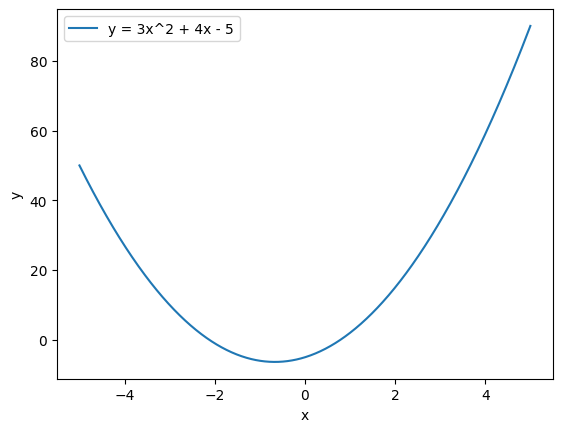

In [2]:
#Creating y = 3x^2 + 4x - 5
X = np.linspace(-5, 5, 1000)
y = 3*(X**2) + 4*X - 5

plt.plot(X, y, label = 'y = 3x^2 + 4x - 5')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()

In [3]:
#Generating the training and validation datasets
n = X.shape[0]
n_val = int(0.2 * n)

idx = np.random.permutation(n)
val_idx, train_idx = idx[:n_val], idx[n_val:]

X_val, y_val = X[val_idx], y[val_idx]

X_train, y_train_true = X[train_idx], y[train_idx]
noise = np.random.normal(0, 5, y_train_true.shape[0])
y_train = y_train_true + noise

Text(0, 0.5, 'y')

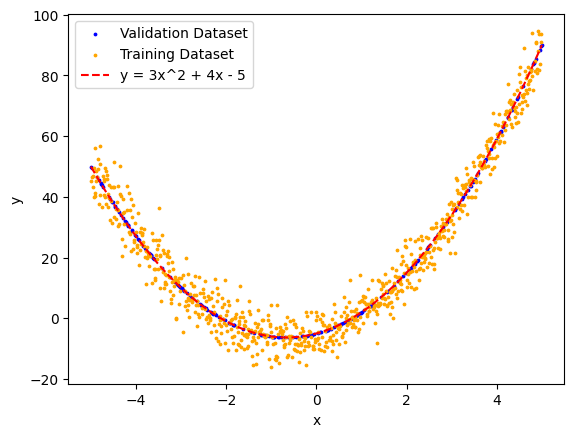

In [4]:
#Plotting the test and train datasets
plt.scatter(X_val, y_val, color = 'blue', label = 'Validation Dataset', s = 3)
plt.scatter(X_train, y_train, color = 'orange', label = 'Training Dataset', s = 3)
plt.plot(X, y, color = 'red', linestyle = '--', label = 'y = 3x^2 + 4x - 5')
plt.legend()
plt.xlabel('x')
plt.ylabel('y')

In [5]:
#Training the 5 different types of ways HOML outlines you can determine the values for Theta for Linear Regression
lin_reg = LinearRegression(type = 'polynomial', degree = 2)
theta_methods = ['normal', 'pseudoinverse', 'batch', 'minibatch', 'stochastic']
gd_methods = ['batch', 'minibatch', 'stochastic']

predicted_values = dict()
thetas = dict()
theta_histories = dict()
cost_histories = dict()

for method in theta_methods:
    lin_reg.fit(X_train, y_train, type = method)
    predicted_values[method] = lin_reg.predict(X_val)
    thetas[method] = lin_reg._theta 

    if method in ['batch', 'minibatch', 'stochastic']:
        theta_histories[method] = lin_reg._theta_history
        cost_histories[method] = lin_reg._cost_history

Initialized a Linear Regression Model


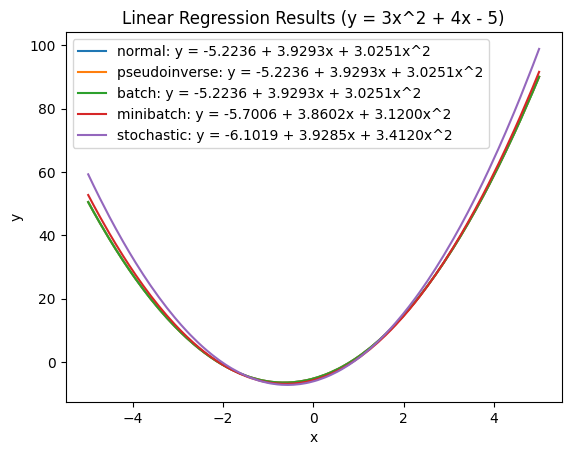

In [25]:
#Plotting the Lines for Linear Regression
plt.title('Linear Regression Results (y = 3x^2 + 4x - 5)')
plt.xlabel('x')
plt.ylabel('y')

for method in theta_methods:
    theta = thetas[method]
    X_val = X_val.flatten()

    sort_idx = np.argsort(X_val)
    X_val = X_val[sort_idx]

    full_X_val = np.column_stack([X_val**i for i in range(1, 3)])
    X_new = np.c_[np.ones(X_val.shape), full_X_val]
    y_pred = X_new @ theta

    plt.plot(X_val, y_pred, label = f'{method}: y = {theta[0]:.4f} + {theta[1]:.4f}x + {theta[2]:.4f}x^2')

plt.legend()